In [1]:
%load_ext autoreload
%autoreload 2

from IPython.display import Math, Latex

import pandas as pd, cvxpy as cp, numpy as np, matplotlib as mpl  # type: ignore
import matplotlib.pyplot as plt  # type: ignore

from matplotlib.ticker import FuncFormatter, MultipleLocator  # type: ignore
from matplotlib.patches import FancyArrowPatch, Polygon  # type: ignore
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from scipy.integrate import quad  # type: ignore
from scipy.spatial import ConvexHull
from scipy.interpolate import interp1d

import importlib, itertools, csv, concurrent.futures
import os, math, sys, json, pickle, shutil, time, functools

from typing import Dict, List, Any, Optional, Literal
from tqdm.notebook import tqdm
import networkx as nx

from Utils import Notebook, tex, gph, sgn, nm, ds
from Simulator import *
# from SimulatorOld import *
from optimization import DisturbedSaturatedPETC as DSPETC

cfg = {
    'style': {'color': 'black'},
    'axis': {
        'title_pad': 10,
        'x_label_fontsize': 16,
        'y_label_fontsize': 16,
        'tick_fontsize': 16,
    },
    'legend': {'fontsize': 16}
}

colors_list = plt.get_cmap('tab20').colors
Notebook.setup()

LaTeX has been enabled for text rendering.


### Definição da Planta

In [2]:
experiment_filename = 'exp-03'

with open(f"experiment-datas/{experiment_filename}.json", encoding='utf-8') as f:
  config = json.load(f)

plant = ds.StateSpace(data=config["plant"], name='plant')
latex_expr = plant.get_latex_equations()
print("Equações que regem a dinâmica da planta:")
tex.display_latex(latex_expr)

Equações que regem a dinâmica da planta:


<IPython.core.display.Latex object>

### Simulação da Planta em Malha Aberta

In [3]:
import Simulator
import matplotlib.pyplot as plt

# Parâmetros
EXPERIMENT_FILE = f"experiment-datas/{experiment_filename}.json"
x0 = [0.1, -0.5]

y_hist, t_hist, u_hist = Simulator.open_loop(
    x0, EXPERIMENT_FILE, u_constant=0.0)

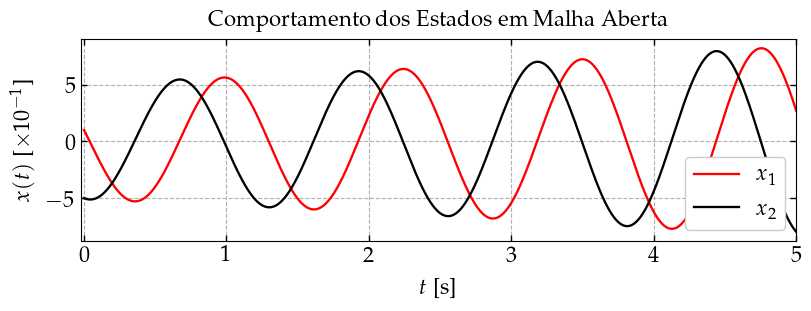

In [4]:
fig = plt.figure(figsize=(8, 3), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

_ = gph.plot(
    axs['x'], t_hist, y_hist,
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'$x(t)$', color=['red', 'black'],
    label=[fr'$x_1$', fr'$x_2$'],
    cfg=cfg, title='Comportamento dos Estados em Malha Aberta',
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

### Projeto do Controlador e do ETM

In [5]:
def solve_problem(
    h: float,
    υ: float,
    eps: float = 1e-6,
):
  n_x = plant.nx
  n_u = plant.nu

  Onx = np.zeros((n_x, n_x))

  matrices = plant.evaluate_matrices(None, None, None)
  A = matrices['A']
  B = matrices['B']

  e = nm.get_e(5 * [n_x])

  for i in range(1, len(e)):
    e[i] = cp.Parameter(e[i].shape, value=e[i], name=f"e{i}")

  constraints = []

  Ptil = cp.Variable((n_x, n_x), PSD=True)
  Mtil = cp.Variable((2 * n_x, 2 * n_x), PSD=True)
  Q1til = cp.Variable((n_x, n_x), symmetric=True)
  Q2til = cp.Variable((n_x, n_x))
  Q3til = cp.Variable((n_x, n_x))
  S1til = cp.Variable((n_x, n_x), symmetric=True)
  S2til = cp.Variable((n_x, n_x))
  S3til = cp.Variable((n_x, n_x))
  Ktil = cp.Variable((n_u, n_x))
  # Ktil = cp.Parameter((n_u, n_x), value=np.array([[1, -3.0]]))

  Rtil = cp.Variable((n_x, n_x), PSD=True)
  Ξtil = cp.Variable((n_x, n_x), PSD=True)
  Ψtil = cp.Variable((n_x, n_x), PSD=True)

  X = cp.Variable((n_x, n_x))
  Ytil = cp.Variable((2 * n_x, e[1].shape[1]))

  Rcal = cp.bmat([[Rtil, Onx],
                  [Onx, 3. * Rtil]])

  Fscr = e[1].T + υ * e[2].T + υ * e[4].T

  κ1 = cp.bmat([[e[2]], [e[5]]])
  κ2 = cp.bmat([[e[1] - e[2]],
                [e[1] + e[2] - 2. * e[3]]])

  def get_Θ(ω):
    Bscr = A @ X @ e[1] + B @ Ktil @ e[2] + + \
        B @ Ktil @ e[5] - X @ e[4]
    Θ1 = (e[1] - e[2]).T @ S1til @ (e[1] - e[2]) + \
        nm.He((e[1] - e[2]).T @ (S2til @ e[2] + S3til @ e[5]))
    Θ2 = nm.He(e[3].T @ (Q2til @ e[2] + Q3til @ e[5]))
    Θ3 = nm.He(e[1].T @ (Q1til @ e[3] + Q2til @ e[2] + Q3til @ e[5]))
    Θ4 = nm.He(e[4].T @ (S1til @ (e[1] - e[2]) + S2til @
               e[2] + S3til @ e[5])) + e[4].T @ Rtil @ e[4]
    return nm.He(e[1].T @ Ptil @ e[4] + Fscr @ Bscr - κ2.T @ Ytil) - e[5].T @ Ξtil @ e[5] - \
        Θ1 - ω * Θ2 - h * e[3].T @ Q1til @ e[3] + \
        (h - ω) * Θ3 + (h - 2.0 * ω) * κ1.T @ Mtil @ κ1 + (h - ω) * Θ4

  def get_Λ():
    Γ1_11 = get_Θ(0)
    Γ1_12 = e[2].T @ X.T

    Γ1_21 = Γ1_12.T
    Γ1_22 = - Ψtil

    Γ1 = cp.bmat([[Γ1_11, Γ1_12],
                  [Γ1_21, Γ1_22]])

    Γ2_11 = get_Θ(h)
    Γ2_12 = Ytil.T
    Γ2_13 = e[2].T @ X.T

    Γ2_21 = Γ2_12.T
    Γ2_22 = - (1. / h) * Rcal
    Γ2_23 = np.zeros((2 * n_x, n_x))

    Γ2_31 = Γ2_13.T
    Γ2_32 = Γ2_23.T
    Γ2_33 = - Ψtil

    Γ2 = cp.bmat([[Γ2_11, Γ2_12, Γ2_13],
                  [Γ2_21, Γ2_22, Γ2_23],
                  [Γ2_31, Γ2_32, Γ2_33]])

    return Γ1, Γ2

  Γ1, Γ2 = get_Λ()
  constraints += [Γ1 << -eps * np.eye(Γ1.shape[0])]
  constraints += [Γ2 << -eps * np.eye(Γ2.shape[0])]

  constraints += [Ψtil >> eps * np.eye(n_x)]
  constraints += [Ξtil >> eps * np.eye(n_x)]

  obj = cp.Minimize(cp.trace(Ξtil + Ψtil))
  prob = cp.Problem(obj, constraints)

  # Solve the problem using the MOSEK solver
  prob.solve(solver=cp.MOSEK, verbose=False, ignore_dpp=True)

  # Initialize variables to store results
  design_results = None

  # Display the results
  if prob.status not in ["infeasible", "unbounded"]:
    Xinv = np.linalg.inv(X.value)
    Ξ = Xinv.T @ Ξtil.value @ Xinv
    Ψ = np.linalg.inv(Ψtil.value)
    P = Xinv.T @ Ptil.value @ Xinv
    S2 = Xinv.T @ S2til.value @ Xinv
    K = Ktil.value @ Xinv
    etm_results = {'Ξ': Ξ, 'Ψ': Ψ}
    design_results = {
        'optimal_value': prob.value,
        'etm': etm_results,
        'controller': {'K': K},
        'lyapunov': [P, S2],
    }
  else:
    design_results = None

  return design_results

In [6]:
sampling_period = config["design_params"]['h']
υ = 1e-1

prob_results = solve_problem(h=sampling_period, υ=υ)

if prob_results is not None:
  Ξ, Ψ = prob_results['etm']['Ξ'], prob_results['etm']['Ψ']
  K = prob_results['controller']['K']
  P, S2 = prob_results['lyapunov']

  display(Math(rf'\Xi = {tex.mat2tex(Ξ)}'))
  display(Math(rf'\Psi = {tex.mat2tex(Ψ)}'))
  display(Math(rf'P = {tex.mat2tex(P)}'))

  display(Math(rf'K = {tex.mat2tex(K)}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
y_hist, t_hist, u_hist, events = closed_loop_setm(
    x0, EXPERIMENT_FILE, prob_results)

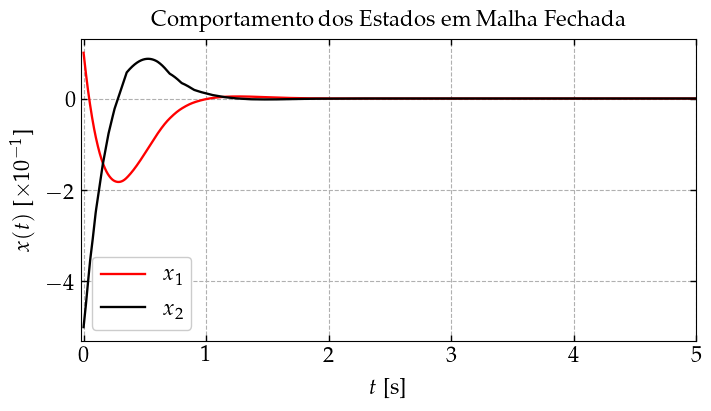

In [8]:
fig = plt.figure(figsize=(7, 4), layout='constrained')
axs = fig.subplot_mosaic([["x"]])

_ = gph.plot(
    axs['x'], t_hist, y_hist,
    xlabel='$t$', x_unit='s', x_use_prefixes=True,
    ylabel=r'$x(t)$', color=['red', 'black'],
    label=[fr'$x_1$', fr'$x_2$'],
    cfg=cfg, title='Comportamento dos Estados em Malha Fechada',
    x_pad=(0.005, 0.0), y_pad=(0.05, 0.05)
)

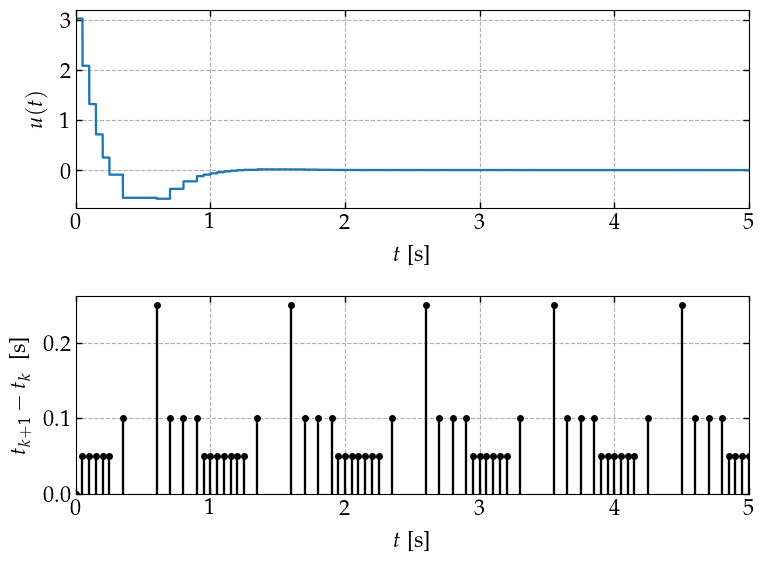

In [9]:
mosaic = [['control'], ['iet']]
fig, axs = plt.subplot_mosaic(mosaic, figsize=(8, 6))

inter_event_times = nm.compute_deltas(events)

for i in range(plant.nu):
  gph.plot(
      axs['control'], t_hist, u_hist, xlabel='$t$', x_unit='s', x_use_prefixes=True,
      ylabel=r'$u(t)$', y_pad=(0.05, 0.05),
      cfg={**cfg, 'style': {'color': colors_list[0], "linestyle": ["-"], }},)

gph.stem(
    axs['iet'], events, inter_event_times,
    reuse_previous=False, y_pad=(0.0, 0.05), x_use_prefixes=True,
    xlabel='$t$', x_unit='s', x_range=(0.0, t_hist[-1]),
    ylabel='$t_{k+1} - t_k\\;$', y_unit='s', y_use_prefixes=True,
    cfg={**cfg, 'limits': {'x_min': 0, 'x_max': t_hist[-1]}})

plt.tight_layout(pad=2.)

In [10]:
def build_symbolic_graph(l, eps, config_path, prob_results):
  """
  Constructs the DiGraph based on parallel symbolic sequences.
  """
  initial_states, _ = projective_eps_net(eps)
  G = nx.DiGraph()

  all_k_seqs = build_symbolic_sequences_parallel(
      initial_states, config_path, prob_results
  )

  for k_seq in all_k_seqs:
    if len(k_seq) > l:
      for i in range(len(k_seq) - l):
        state_curr = tuple(k_seq[i: i + l])
        state_next = tuple(k_seq[i + 1: i + l + 1])
        G.add_edge(state_curr, state_next, weight=state_curr[0])

  return G, initial_states


L_WORD = 2
EPSILON = 1e-3

G_sampled, states = build_symbolic_graph(
    L_WORD, EPSILON, EXPERIMENT_FILE, prob_results)

print(
    f"Nodes: {G_sampled.number_of_nodes()} | Edges: {G_sampled.number_of_edges()}")

Nodes: 11 | Edges: 13


In [11]:
k_sequence_raw = np.round(
    np.array(inter_event_times[1:]) / sampling_period).astype(int).tolist()
sequence_nodes = [tuple(k_sequence_raw[i: i + L_WORD])
                  for i in range(len(k_sequence_raw) - L_WORD + 1)]

visualize_graph(G_sampled, sequence_nodes, "sampled_model.html")

In [12]:
import numpy as np
from scipy.signal import cont2discrete
from z3 import Solver, Real, sat, Q
from fractions import Fraction as PyFraction


class SequenceReconstructor:
  """
  Reconstrutor de estados iniciais (x0) compatíveis com uma sequência de eventos 
  pré-definida em sistemas de controle baseados em eventos (ETC/SETM).

  Utiliza Z3 para resolver as restrições quadráticas de disparo.
  """

  def __init__(self, A_c, B_c, K, Xi, Psi, h, iet_max):
    """
    Inicializa o reconstrutor e pré-calcula as matrizes de transição e gatilho.

    Args:
        A_c, B_c: Matrizes do sistema contínuo.
        K: Ganho do controlador.
        Xi, Psi: Matrizes de peso do mecanismo de gatilho.
        h: Passo de discretização.
        iet_max: Tempo máximo entre eventos.
    """
    self.nx = A_c.shape[0]
    self.h = h
    self.m_max = int(round(iet_max / h))

    sys_d = cont2discrete((A_c, B_c, np.zeros((1, self.nx)),
                           np.zeros((1, B_c.shape[1]))), h, method='zoh')
    self.Ad, self.Bd = sys_d[0], sys_d[1]

    self.Phi_cache = [None] * (self.m_max + 1)
    self.M_cache = [None] * (self.m_max + 1)

    I = np.eye(self.nx)
    self.Phi_cache[0] = I

    for m in range(1, self.m_max + 1):
      Ad_pow_m = np.linalg.matrix_power(self.Ad, m)
      S_m = np.zeros_like(self.Ad)
      for p in range(m):
        S_m += np.linalg.matrix_power(self.Ad, p)
      Phi_m = Ad_pow_m + S_m @ self.Bd @ K
      self.Phi_cache[m] = Phi_m
      diff = I - Phi_m
      M_val = (Phi_m.T @ Psi @ Phi_m) - (diff.T @ Xi @ diff)
      self.M_cache[m] = M_val

  def _to_rational(self, matrix):
    return [[Q(PyFraction(val).limit_denominator(10**10).numerator,
               PyFraction(val).limit_denominator(10**10).denominator)
             for val in row] for row in matrix]

  def find_compatible_state(self, sequence):
    """
    Busca um vetor x0 não-nulo que gere exatamente a sequência de eventos fornecida.

    Args:
        sequence (list[int]): Lista de intervalos entre eventos (em passos h).

    Returns:
        np.array: Vetor de estado x0 válido, ou None se a sequência for impossível.
    """
    solver = Solver()
    x0 = [Real(f'x0_{i}') for i in range(self.nx)]
    solver.add(sum([x * x for x in x0]) > Q(1, 1000))
    G_acc = np.eye(self.nx)

    for m_target in sequence:
      if m_target > self.m_max:
        return None

      for k in range(1, m_target):
        M_k = self.M_cache[k]
        M_proj = G_acc.T @ M_k @ G_acc
        M_z3 = self._to_rational(M_proj)

        quad_form = sum(x0[r] * M_z3[r][c] * x0[c]
                        for r in range(self.nx) for c in range(self.nx))
        solver.add(quad_form >= 0)

      if m_target < self.m_max:
        M_target_mat = self.M_cache[m_target]
        M_proj_trig = G_acc.T @ M_target_mat @ G_acc
        M_z3_trig = self._to_rational(M_proj_trig)

        quad_form_trig = sum(x0[r] * M_z3_trig[r][c] * x0[c]
                             for r in range(self.nx) for c in range(self.nx))
        solver.add(quad_form_trig < 0)

      G_acc = self.Phi_cache[m_target] @ G_acc

    if solver.check() == sat:
      model = solver.model()
      return np.array([float(model[v].as_fraction()) for v in x0])
    else:
      return None

In [13]:
def build_symbolic_exactly_graph(target_l, K_set, h, A, B, K, Xi, Psi, iet_max):
  """
  Constrói o grafo simbólico crescendo progressivamente o tamanho das palavras.
  Complexidade reduzida drasticamente ao descartar ramos inviáveis cedo.
  """
  print(f"=== [Init] Pré-calculando dinâmicas (Z3 Backend) ===")
  reconstructor = SequenceReconstructor(A, B, K, Xi, Psi, h, iet_max)
  valid_sequences = []
  print(f"--- Camada 1 ---")
  for k in K_set:
    seq = (k,)
    if reconstructor.find_compatible_state(seq) is not None:
      valid_sequences.append(seq)

  for length in range(2, target_l + 1):
    print(f"--- Camada {length} ---")
    next_valid_sequences = []
    candidates_count = len(valid_sequences) * len(K_set)

    for seq in valid_sequences:
      for k_next in K_set:
        candidate = seq + (k_next,)

        if reconstructor.find_compatible_state(candidate) is not None:
          next_valid_sequences.append(candidate)

    dropped = candidates_count - len(next_valid_sequences)
    print(
        f"   Candidatos: {candidates_count} | Válidos: {len(next_valid_sequences)} | Podados: {dropped}")

    if not next_valid_sequences:
      print("AVISO: Nenhuma sequência válida encontrada neste comprimento!")
      break

    valid_sequences = next_valid_sequences

  feasible_nodes = valid_sequences
  feasible_nodes_set = set(feasible_nodes)
  G = nx.DiGraph()
  G.add_nodes_from(feasible_nodes)

  print(
      f"=== [Edges] Gerando arestas (Extensão para tam {target_l + 1}) ===")
  count_edges = 0

  for node_a in feasible_nodes:
    suffix = node_a[1:]

    for k_next in K_set:
      node_b = suffix + (k_next,)

      if node_b in feasible_nodes_set:
        transition_seq = node_a + (k_next,)
        if reconstructor.find_compatible_state(transition_seq) is not None:
          G.add_edge(
              node_a,
              node_b,
              weight=node_a[0],
              label=str(node_a[0])
          )
          count_edges += 1

  print("\n=== Relatório Final ===")
  print(f"Nós Finais: {len(feasible_nodes)}")
  print(f"Arestas:    {count_edges}")

  return G

In [14]:
l = 2
K_set = [1, 2, 3, 4, 5]
h = sampling_period
iet_max = config["design_params"]['iet_max']

Ξ = prob_results['etm']['Ξ']
Ψ = prob_results['etm']['Ψ']
K_control = prob_results['controller']['K']
A, B, _, _ = plant.export_matrices_jit()

# Chamada da Função
G_complete = build_symbolic_exactly_graph(
    target_l=l, K_set=K_set, h=h, A=A,
    B=B, K=K_control, Xi=Ξ, Psi=Ψ, iet_max=iet_max
)

print(
    f"\nGrafo gerado com {G_complete.number_of_nodes()} nós e {G_complete.number_of_edges()} arestas.")

=== [Init] Pré-calculando dinâmicas (Z3 Backend) ===
--- Camada 1 ---
--- Camada 2 ---
   Candidatos: 25 | Válidos: 11 | Podados: 14
=== [Edges] Gerando arestas (Extensão para tam 3) ===

=== Relatório Final ===
Nós Finais: 11
Arestas:    13

Grafo gerado com 11 nós e 13 arestas.


In [15]:
visualize_graph(G_complete, None, "complete_model.html")

In [16]:
iet_max = config["design_params"]['iet_max']
h = sampling_period

A, B, _, _ = plant.export_matrices_jit()
K = prob_results['controller']['K']
Xi = prob_results['etm']['Ξ']
Psi = prob_results['etm']['Ψ']

sequence = (2, 1, 1, 1, 1, 1, 1, 2)

reconstructor = SequenceReconstructor(A, B, K, Xi, Psi, h, iet_max)

print(f"=== Buscando estado inicial para a sequência: {sequence} ===")

x0_exact = reconstructor.find_compatible_state(sequence)

if x0_exact is not None:
  x0_exact_norm = x0_exact / np.linalg.norm(x0_exact)
  print(f"Estado inicial encontrado (norm): {x0_exact_norm}")

  x0_sim = x0_exact_norm

  _, _, _, events = closed_loop_setm(x0_sim, EXPERIMENT_FILE, prob_results)

  if len(events) > 1:
    inter_event_times = np.diff(events)
    k_simulated = inter_event_times / h

    print("\n--- Validação Cruzada (Simulador C++) ---")
    print("Obtido (k):", k_simulated[:len(sequence)])

    k_rounded = np.round(k_simulated[:len(sequence)]).astype(int)
    is_match = np.all(k_rounded == np.array(sequence))

    if is_match:
      print("Resultado: ✅ Sucesso Absoluto")
    else:
      print("Resultado: ⚠️ Divergência Numérica")
  else:
    print("Aviso: A simulação não gerou eventos suficientes para validar a sequência inteira.")

else:
  print(
      f"❌ A sequência {sequence} é fisicamente impossível para este sistema.")

=== Buscando estado inicial para a sequência: (2, 1, 1, 1, 1, 1, 1, 2) ===
Estado inicial encontrado (norm): [-0.49613894  0.86824314]

--- Validação Cruzada (Simulador C++) ---
Obtido (k): [2. 1. 1. 1. 1. 1. 1. 2.]
Resultado: ✅ Sucesso Absoluto
